# 0. Setup (data access + imports)

In [1]:
# @hidden_cell
# The project token is an authorization token that is used to access project resources like data sources, connections, and used by platform APIs.
from project_lib import Project
project = Project(project_id='a4b0ee86-eb55-4880-a0a9-dafb3cb3d209', project_access_token='p-2+9db6CplsWEz0YcUMYrb6vw==;XhW7/JkVA4DsLH0ajK0gVg==:mah8rhFREnk/bQaF5cZeBBCqhJ11/8MP4r5uOPGm6UKCUNCfibEBwKDqwEB4zW6Y4qnalntwfbW4t23Yp/LzVqy4eosPja7e6w==')
pc = project.project_context

from ibm_watson_studio_lib import access_project_or_space
wslib = access_project_or_space({'token':'p-2+9db6CplsWEz0YcUMYrb6vw==;XhW7/JkVA4DsLH0ajK0gVg==:mah8rhFREnk/bQaF5cZeBBCqhJ11/8MP4r5uOPGm6UKCUNCfibEBwKDqwEB4zW6Y4qnalntwfbW4t23Yp/LzVqy4eosPja7e6w=='})


In [2]:
import os, types
import pandas as pd
from botocore.client import Config
import ibm_boto3

def __iter__(self): return 0

# @hidden_cell
# The following code accesses a file in your IBM Cloud Object Storage. It includes your credentials.
# You might want to remove those credentials before you share the notebook.

cos_client = ibm_boto3.client(service_name='s3',
    ibm_api_key_id='Je80jteW7WGVB2R3X1tUbWvC0unUWdf6uJv1ShyZapMb',
    ibm_auth_endpoint="https://iam.cloud.ibm.com/identity/token",
    config=Config(signature_version='oauth'),
    endpoint_url='https://s3.direct.us-south.cloud-object-storage.appdomain.cloud')

bucket = 'team3pimrosenanthayapirom-donotdelete-pr-8gp1oisiqzdokh'
object_key = 'elon_tweets_clean.csv'

body = cos_client.get_object(Bucket=bucket,Key=object_key)['Body']
# add missing __iter__ method, so pandas accepts body as file-like object
if not hasattr(body, "__iter__"): body.__iter__ = types.MethodType( __iter__, body )

df_1 = pd.read_csv(body)
df_1.head(10)

/tmp/wsuser/ipykernel_88/3261039769.py:25: DtypeWarning: Columns (3,14,15,16,17,21,22,23,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df_1 = pd.read_csv(body)


,tweet_id,tweet_idx,year,has_intelligence_keywords,n_windows,retweet_count,reply_count,like_count,quote_count,view_count,...,has_retweet_count,has_reply_count,has_like_count,has_quote_count,has_view_count,has_bookmark_count,flag_non_alpha_text,flag_very_short_text,tweet_date,tweet_time
0,15434727182,6909.0,2010.0,False,0.0,697.0,1422.0,6392.0,400.0,NaN,...,True,True,True,True,False,True,False,False,2010-06-04,18:31:57
1,142179928203460608,6908.0,2011.0,False,0.0,27.0,40.0,197.0,9.0,NaN,...,True,True,True,True,False,True,False,False,2011-12-01,09:55:11
2,142188458125963264,6907.0,2011.0,False,0.0,19.0,43.0,124.0,8.0,NaN,...,True,True,True,True,False,True,False,False,2011-12-01,10:29:04
3,142880871391838208,6906.0,2011.0,False,0.0,36.0,31.0,87.0,7.0,NaN,...,True,True,True,True,False,True,False,False,2011-12-03,08:20:28
4,142881284019060736,6905.0,2011.0,False,0.0,12.0,42.0,133.0,9.0,NaN,...,True,True,True,True,False,True,False,False,2011-12-03,08:22:07
5,143171132814671872,6904.0,2011.0,False,0.0,39.0,41.0,251.0,34.0,NaN,...,True,True,True,True,False,True,False,False,2011-12-04,03:33:52
6,149435658115612672,6903.0,2011.0,False,0.0,75.0,28.0,330.0,38.0,NaN,...,True,True,True,True,False,True,False,False,2011-12-21,10:26:51
7,149436471764459520,6902.0,2011.0,False,0.0,27.0,14.0,120.0,14.0,NaN,...,True,True,True,True,False,True,False,False,2011-12-21,10:30:05
8,149439686702661632,6901.0,2011.0,False,0.0,16.0,32.0,133.0,15.0,NaN,...,True,True,True,True,False,True,False,False,2011-12-21,10:42:52
9,149441101684686848,6900.0,2011.0,False,0.0,11.0,11.0,46.0,1.0,NaN,...,True,True,True,True,False,True,False,False,2011-12-21,10:48:29


In [3]:
# Sanity check: required columns already exist from Cell 2
print("Rows:", len(df_1))
print("Missing word_count:", df_1["word_count"].isna().sum())
print("Year range:", df_1["year"].min(), "-", df_1["year"].max())


Rows: 55108
Missing word_count: 0
Year range: 2010.0 - 2025.0


## Install/Imports

In [4]:
# Core scientific stack
!pip -q install numpy pandas scipy scikit-learn

# Visualization
!pip -q install matplotlib seaborn

# Embeddings + NLP
#!pip -q install "sentence-transformers==2.7.0.dev0" transformers torch
#%pip install -q sentence-transformers transformers

# Dimensionality reduction
!pip -q install umap-learn

# Sentiment / text utilities (optional but likely needed)
!pip -q install nltk emoji

#%pip install --no-cache-dir --force-reinstall "transformers==4.37.2" "sentence-transformers==2.6.1"

In [5]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Distance & metrics
from sklearn.metrics.pairwise import cosine_distances

# Embeddings
from sentence_transformers import SentenceTransformer

# Dimensionality reduction
import umap

# Text utilities
import re
import emoji

2026-03-03 18:33:25.658044: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772562805.676365      88 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772562805.681871      88 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [6]:
import importlib.util

packages = [
    "numpy", "pandas", "sklearn", "matplotlib",
    "sentence_transformers", "torch", "umap", "emoji"
]

for p in packages:
    print(p, "→", importlib.util.find_spec(p) is not None)

numpy → True
pandas → True
sklearn → True
matplotlib → True
sentence_transformers → True
torch → True
umap → True
emoji → True


# PART 1 Behavioral Shift & Length Definition

## Distribution of tweet length (word count) & Log Scale

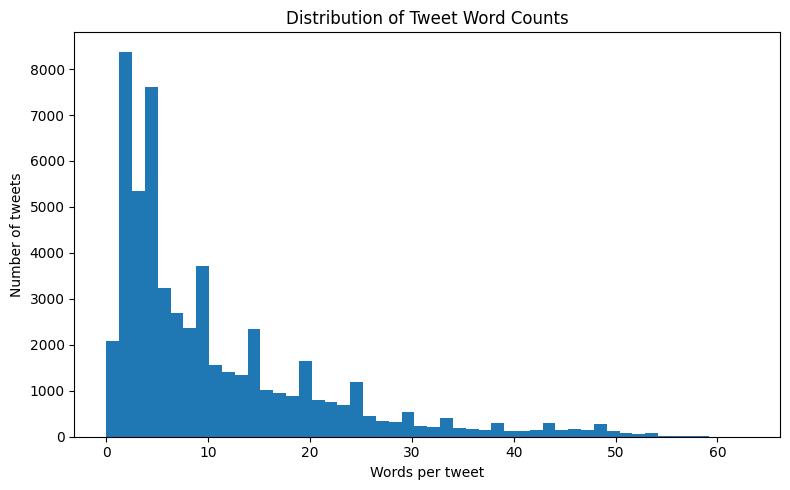

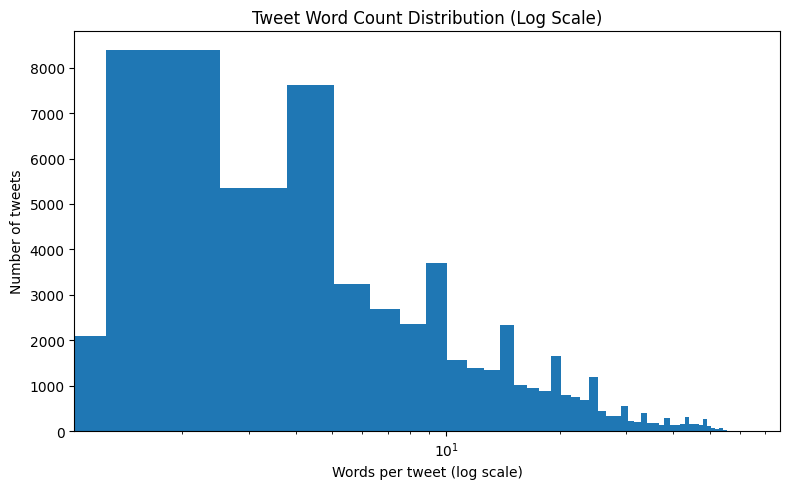

In [8]:
# Distribution of tweet length (word count)
plt.figure(figsize=(8,5))
plt.hist(df_1["word_count"].dropna(), bins=50)
plt.xlabel("Words per tweet")
plt.ylabel("Number of tweets")
plt.title("Distribution of Tweet Word Counts")
plt.tight_layout()
plt.show()

# Log scale
plt.figure(figsize=(8,5))
plt.hist(df_1["word_count"].dropna(), bins=50)
plt.xscale("log")
plt.xlabel("Words per tweet (log scale)")
plt.ylabel("Number of tweets")
plt.title("Tweet Word Count Distribution (Log Scale)")
plt.tight_layout()
plt.show()

## Median tweet length by year

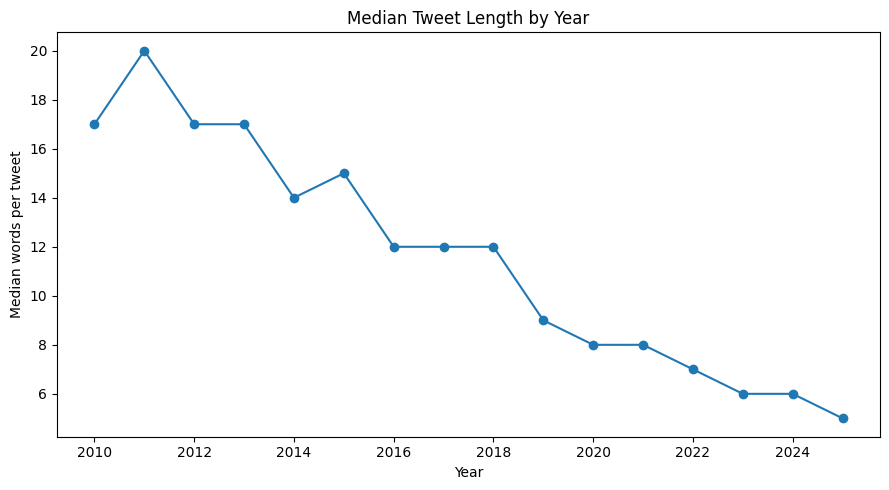

In [9]:
median_len_by_year = (
    df_1.groupby("year")["word_count"]
        .median()
        .reset_index()
)

plt.figure(figsize=(9,5))
plt.plot(
    median_len_by_year["year"],
    median_len_by_year["word_count"],
    marker="o"
)
plt.xlabel("Year")
plt.ylabel("Median words per tweet")
plt.title("Median Tweet Length by Year")
plt.tight_layout()
plt.show()

## Tweet Volume per Year

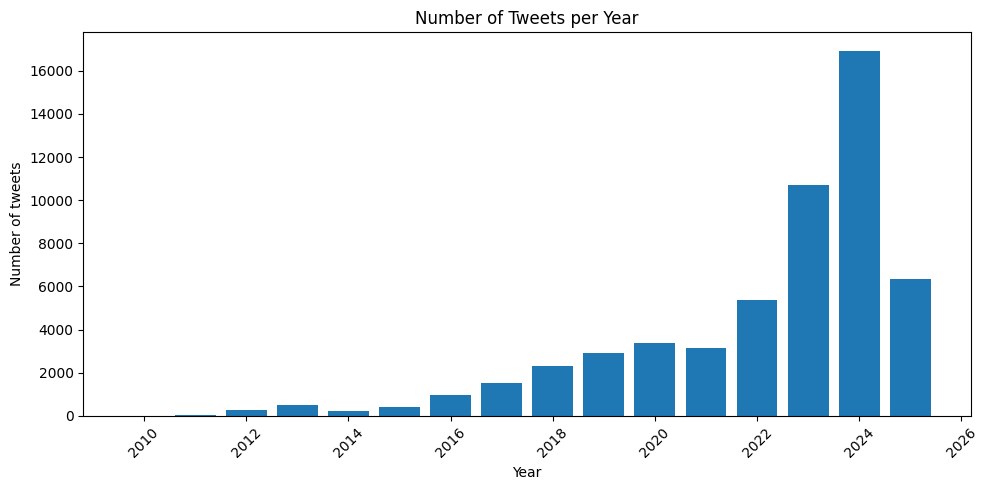

count       16.000000
mean      3443.687500
std       4615.510296
min          1.000000
25%        384.500000
50%       1908.000000
75%       3876.500000
max      16938.000000
Name: num_tweets, dtype: float64

In [11]:
tweets_per_year = (
    df_1.groupby("year")["tweet_id"]
        .nunique()
        .reset_index(name="num_tweets")
)

plt.figure(figsize=(10,5))
plt.bar(tweets_per_year["year"], tweets_per_year["num_tweets"])
plt.xlabel("Year")
plt.ylabel("Number of tweets")
plt.title("Number of Tweets per Year")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

tweets_per_year["num_tweets"].describe()

## Short / Medium / Long tweet length bucket by global percentiles
30/70 shows a more balanced, although 35/65 could work, but 30/70 preserved a clear middle category while maintaining balanced group sizes, making interpretations more straightforward.

In [13]:
percentile_sets = {
    "25_75": (0.25, 0.75),
    "30_70": (0.30, 0.70),
    "35_65": (0.35, 0.65)
}
results = []

for label, (low, high) in percentile_sets.items():
    q_low = df_1["word_count"].quantile(low)
    q_high = df_1["word_count"].quantile(high)
    
    buckets = pd.cut(
        df_1["word_count"],
        bins=[-np.inf, q_low, q_high, np.inf],
        labels=["short", "medium", "long"]
    )
    
    shares = buckets.value_counts(normalize=True)
    
    results.append({
        "scheme": label,
        "short": shares.get("short", 0),
        "medium": shares.get("medium", 0),
        "long": shares.get("long", 0)
    })

pd.DataFrame(results)

,scheme,short,medium,long
0,25_75,0.287000,0.476410,0.236590
1,30_70,0.360274,0.360637,0.279088
2,35_65,0.360274,0.310880,0.328845


In [14]:
# Define data-driven length buckets using percentiles
q30 = df_1["word_count"].quantile(0.30)
q70 = df_1["word_count"].quantile(0.70)

df_1["length_bucket"] = pd.cut(
    df_1["word_count"],
    bins=[-np.inf, q30, q70, np.inf],
    labels=["short", "medium", "long"]
)

# Check proportions
df_1["length_bucket"].value_counts(normalize=True)

length_bucket
medium    0.360637
short     0.360274
long      0.279088
Name: proportion, dtype: float64

## Bucket composition over time
Tweet length composition shows a clear shift over time. In earlier years, longer and medium-length tweets make up a larger share of Musk’s output. As tweet volume increases in later years, the proportion of short tweets rises steadily, while the share of long tweets declines. This pattern suggests a move toward more frequent, shorter-form communication rather than longer, explanatory posts.

In [15]:
bucket_share_by_year = (
    df_1.groupby(["year", "length_bucket"])
        .size()
        .reset_index(name="n")
)

bucket_share_by_year["share"] = (
    bucket_share_by_year
        .groupby("year")["n"]
        .transform(lambda x: x / x.sum())
)

bucket_share_by_year.head()

/tmp/wsuser/ipykernel_88/2570843910.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_1.groupby(["year", "length_bucket"])


,year,length_bucket,n,share
0,2010.0,short,0,0.000000
1,2010.0,medium,0,0.000000
2,2010.0,long,1,1.000000
3,2011.0,short,2,0.047619
4,2011.0,medium,7,0.166667


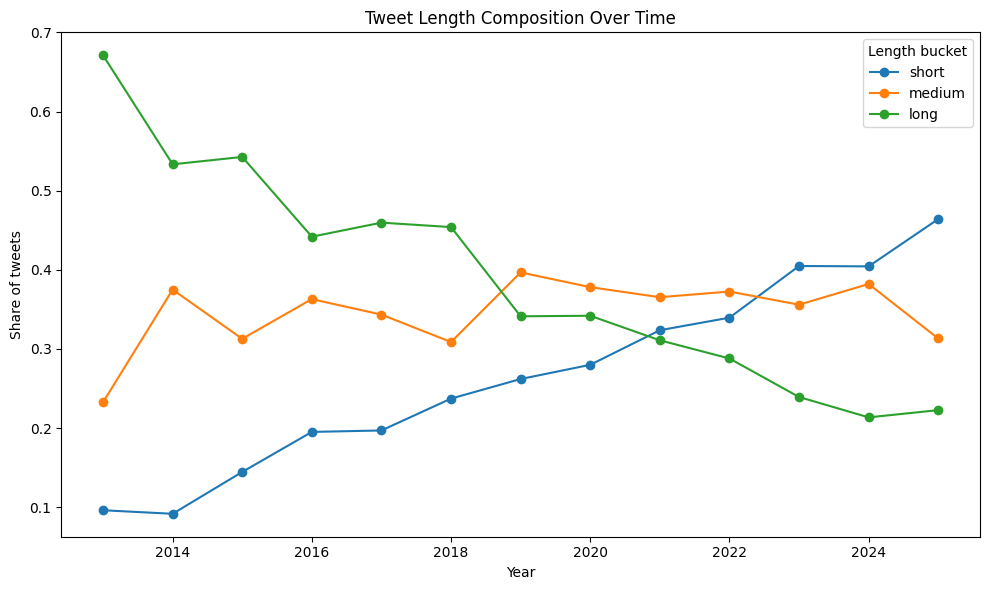

In [16]:
# Filter out early years with very small tweet volumes
plot_df = bucket_share_by_year[bucket_share_by_year["year"] >= 2013]

plt.figure(figsize=(10, 6))

for bucket in ["short", "medium", "long"]:
    subset = plot_df[plot_df["length_bucket"] == bucket]
    plt.plot(
        subset["year"],
        subset["share"],
        marker="o",
        label=bucket
    )

plt.xlabel("Year")
plt.ylabel("Share of tweets")
plt.title("Tweet Length Composition Over Time")
plt.legend(title="Length bucket")
plt.tight_layout()
plt.show()

# PART 2

In [17]:
import re
import pandas as pd

def make_embed_text(s: str) -> str:
    if pd.isna(s):
        return ""
    s = str(s)

    # Remove @mentions (including @user placeholder)
    s = re.sub(r"@\w+", " ", s)

    # Remove URLs
    s = re.sub(r"http\S+|www\.\S+", " ", s)

    # Remove RT at start (retweet marker)
    s = re.sub(r"^RT\s+", " ", s)

    # Turn hashtags into plain words (keep the word, drop '#')
    s = re.sub(r"#(\w+)", r"\1", s)

    # Remove extra non-text artifacts (optional but safe)
    s = re.sub(r"\s+", " ", s).strip()

    return s

df_1["text_embed"] = df_1["text_clean"].apply(make_embed_text)
df_1[["text_clean", "text_embed"]].head()

,text_clean,text_embed
0,"please ignore prior tweets, as that was someon...","please ignore prior tweets, as that was someon..."
1,went to iceland on sat to ride bumper cars on ...,went to iceland on sat to ride bumper cars on ...
2,i made the volume on the model s go to 11. now...,i made the volume on the model s go to 11. now...
3,"great voltaire quote, arguably better than twa...","great voltaire quote, arguably better than twa..."
4,that was a total non sequitur btw,that was a total non sequitur btw


## Embedding (Snowflake)

In [18]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("Snowflake/snowflake-arctic-embed-m")

mini_texts = df_1["text_embed"].fillna("").astype(str).tolist()[:32]
mini_emb = model.encode(
    mini_texts,
    batch_size=32,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print(mini_emb.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/107 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/738 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

(32, 768)


In [19]:
from sentence_transformers import SentenceTransformer
import numpy as np

texts = df_1["text_embed"].fillna("").astype(str).tolist()

model = SentenceTransformer("Snowflake/snowflake-arctic-embed-m")
#model.max_seq_length = 128  # tweets are short; speeds up a lot

# Use multiple CPU processes
#pool = model.start_multi_process_pool()
#embeddings = model.encode_multi_process(texts, pool, batch_size=128)
#model.stop_multi_process_pool(pool)


embeddings = model.encode(
    texts,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True

)



df_1["embedding_arctic"] = list(embeddings)
print("Embeddings created:", embeddings.shape)

Batches:   0%|          | 0/431 [00:00<?, ?it/s]

Embeddings created: (55108, 768)


In [21]:
import numpy as np

df_topic = df_1[
    ["tweet_id", "year", "length_bucket", "text_embed", "embedding_arctic"]
].copy()

df_topic = df_topic.dropna(subset=["length_bucket", "embedding_arctic"])

# Ensure numpy arrays
df_topic["embedding_arctic"] = df_topic["embedding_arctic"].apply(
    lambda x: np.array(x) if not isinstance(x, np.ndarray) else x
)

print("Rows in topic analysis:", len(df_topic))
print(df_topic["length_bucket"].value_counts())

Rows in topic analysis: 55108
length_bucket
medium    19874
short     19854
long      15380
Name: count, dtype: int64


## UMAP
### 🟢 Long tweets (green)

Very concentrated in the center
Form tight clusters
High density
Low dispersion
Interpretation:
- Long tweets tend to revolve around a smaller number of consistent semantic themes.
- This suggests lower topic diversity.

### 🟠 Medium tweets (orange)
Slightly more spread than long
Still mostly inside central mass
Some mild outward expansion
Interpretation:
- Medium tweets show moderate semantic variation.

### 🔵 Short tweets (blue)

Many inside center
But a LOT scattered far out
Many isolated peripheral points
Some clear outliers
Interpretation:
- Short tweets exhibit much broader semantic dispersion.
- This visually supports:
- Short tweets may be more reactive, varied, or less topically consistent.

Running UMAP on 55,108 tweets...
UMAP(n_jobs=1, random_state=42, verbose=True)
Tue Mar  3 18:42:23 2026 Construct fuzzy simplicial set


/opt/user-env/pyt6cuda/lib64/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Tue Mar  3 18:42:23 2026 Finding Nearest Neighbors
Tue Mar  3 18:42:23 2026 Building RP forest with 17 trees
Tue Mar  3 18:42:31 2026 NN descent for 16 iterations
	 1  /  16
	 2  /  16
	 3  /  16
	 4  /  16
	 5  /  16
	Stopping threshold met -- exiting after 5 iterations
Tue Mar  3 18:42:49 2026 Finished Nearest Neighbor Search
Tue Mar  3 18:42:51 2026 Construct embedding


/opt/user-env/pyt6cuda/lib64/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/opt/user-env/pyt6cuda/lib64/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Tue Mar  3 18:44:44 2026 Finished embedding
UMAP complete!


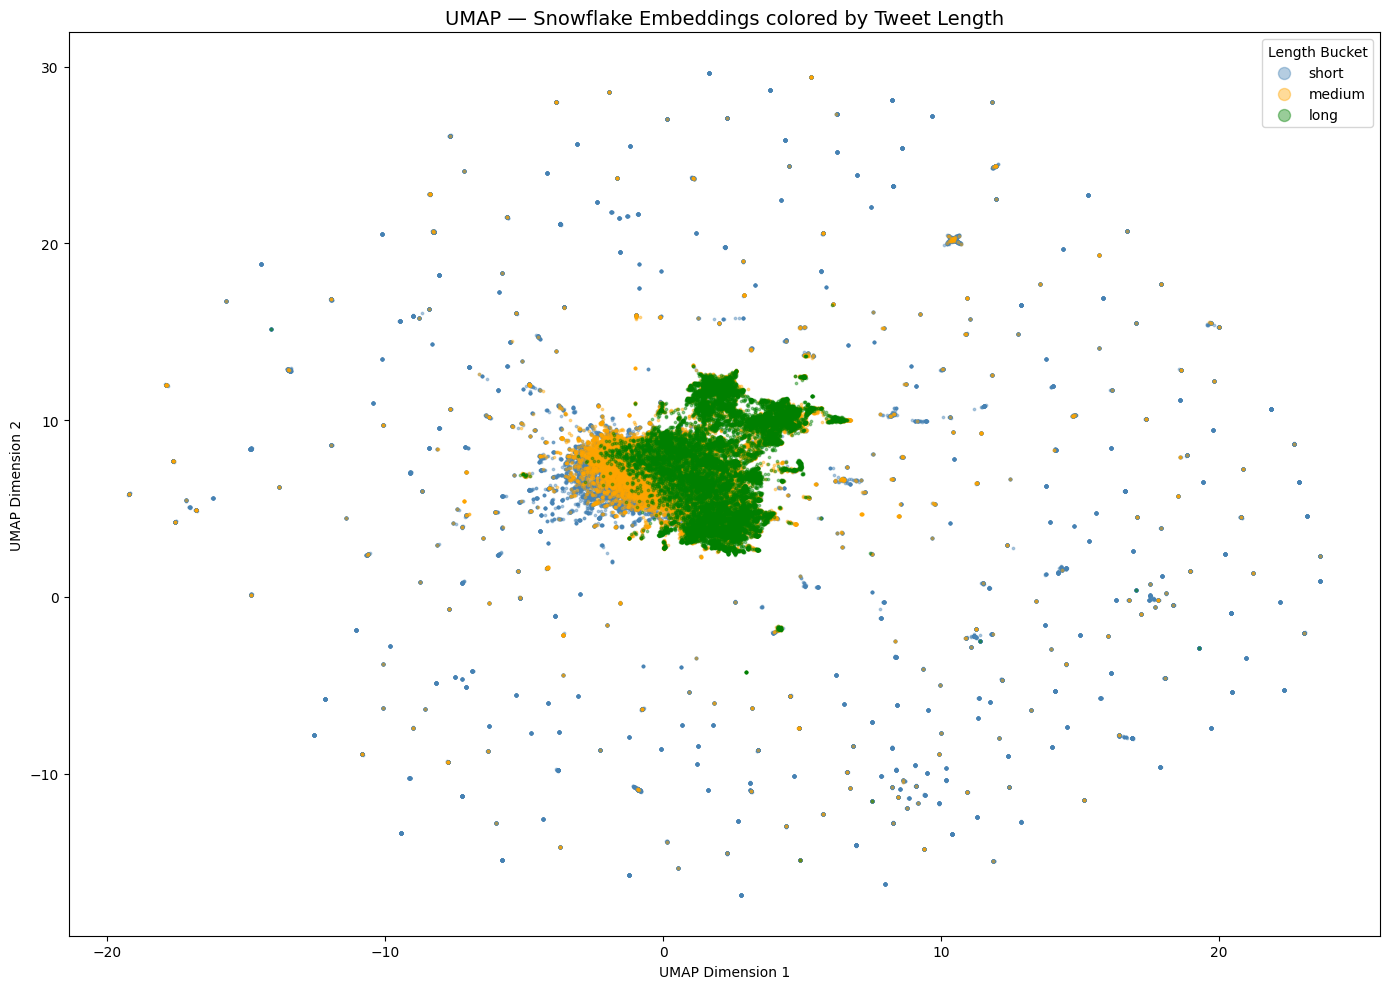

Saved!


In [22]:
import umap.umap_ as umap
import matplotlib.pyplot as plt
import numpy as np

# Stack embeddings into matrix
embedding_matrix = np.stack(df_topic["embedding_arctic"].values)

print(f"Running UMAP on {len(embedding_matrix):,} tweets...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42, verbose=True)
umap_embeddings = reducer.fit_transform(embedding_matrix)
print("UMAP complete!")

# Color by length_bucket
colors = {"short": "steelblue", "medium": "orange", "long": "green"}

plt.figure(figsize=(14, 10))
for bucket in ["short", "medium", "long"]:
    mask = df_topic["length_bucket"] == bucket
    plt.scatter(
        umap_embeddings[mask, 0],
        umap_embeddings[mask, 1],
        c=colors[bucket],
        label=bucket,
        alpha=0.4,
        s=3
    )

plt.title("UMAP — Snowflake Embeddings colored by Tweet Length", fontsize=14)
plt.legend(markerscale=5, title="Length Bucket")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.tight_layout()
plt.savefig("umap_length_bucket.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

UMAP input shape: (55108, 768)
Sampled UMAP shape: (30000, 768)


/opt/user-env/pyt6cuda/lib64/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


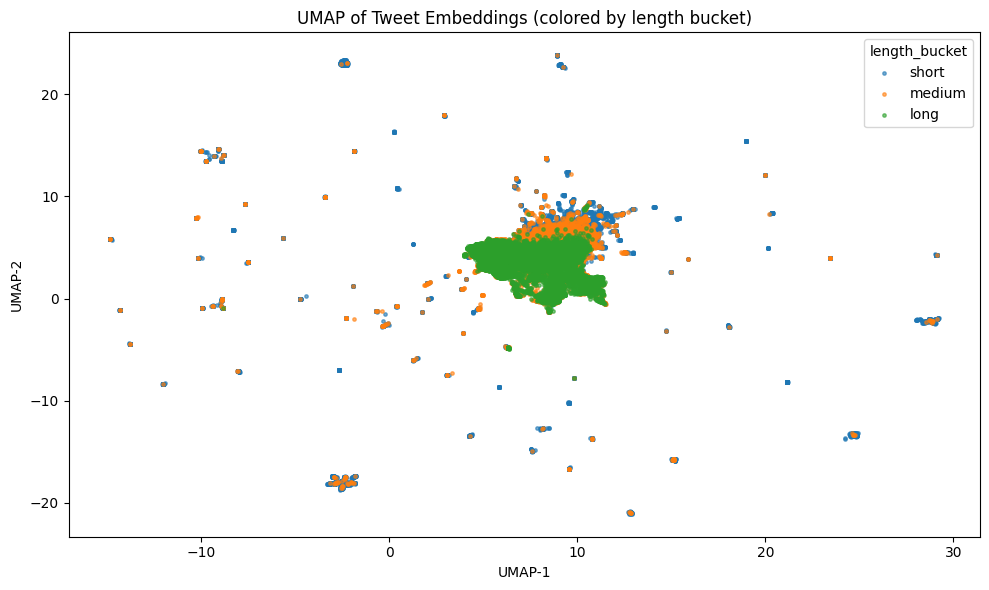

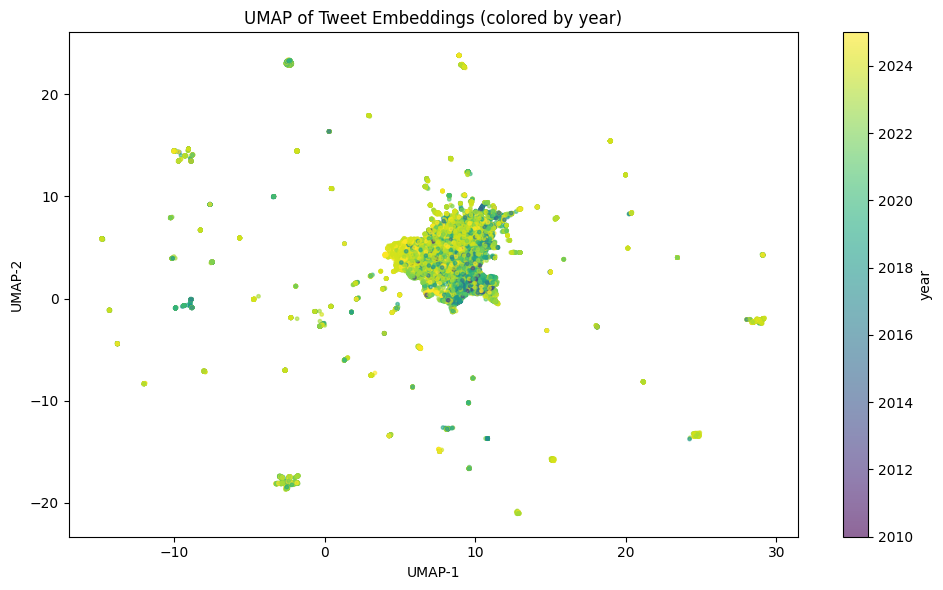

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap

# --- 1) Build embedding matrix X ---
# df_1["embedding_arctic"] is a list of numpy vectors
mask = df_1["embedding_arctic"].notna()
df_umap = df_1.loc[mask, ["year", "length_bucket", "embedding_arctic"]].copy()

X = np.vstack(df_umap["embedding_arctic"].values)  # shape: (N, 768)

print("UMAP input shape:", X.shape)

# --- 2) (Optional but recommended) sample for speed if N is huge ---
# Comment this out if you want ALL points
MAX_N = 30000
if X.shape[0] > MAX_N:
    df_umap = df_umap.sample(MAX_N, random_state=42)
    X = np.vstack(df_umap["embedding_arctic"].values)
    print("Sampled UMAP shape:", X.shape)

# --- 3) Fit UMAP ---
# Since you normalized embeddings, cosine is a good metric
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.10,
    metric="cosine",
    random_state=42
)

coords = reducer.fit_transform(X)
df_umap["umap_x"] = coords[:, 0]
df_umap["umap_y"] = coords[:, 1]

# --- 4A) Plot colored by length_bucket ---
plt.figure(figsize=(10, 6))
for b in ["short", "medium", "long"]:
    sub = df_umap[df_umap["length_bucket"] == b]
    plt.scatter(sub["umap_x"], sub["umap_y"], s=6, alpha=0.6, label=b)

plt.title("UMAP of Tweet Embeddings (colored by length bucket)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(title="length_bucket")
plt.tight_layout()
plt.show()

# --- 4B) Plot colored by year (continuous color scale) ---
plt.figure(figsize=(10, 6))
plt.scatter(df_umap["umap_x"], df_umap["umap_y"], c=df_umap["year"], s=6, alpha=0.6)
plt.title("UMAP of Tweet Embeddings (colored by year)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.colorbar(label="year")
plt.tight_layout()
plt.show()

## Cosine Dispersion

In [24]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# Keep only rows with embeddings
df_disp = df_1[df_1["embedding_arctic"].notna()].copy()

# Convert list of vectors to matrix
X = np.vstack(df_disp["embedding_arctic"].values)

# Store matrix back aligned
df_disp["embedding_matrix_index"] = range(len(df_disp))

# Function to compute centroid dispersion per bucket
results = []

for bucket in df_disp["length_bucket"].unique():
    
    sub = df_disp[df_disp["length_bucket"] == bucket]
    idx = sub["embedding_matrix_index"].values
    
    emb = X[idx]
    
    # Compute centroid
    centroid = emb.mean(axis=0, keepdims=True)
    
    # Compute cosine similarity to centroid
    sims = cosine_similarity(emb, centroid).flatten()
    
    # Convert to cosine distance
    distances = 1 - sims
    
    results.append({
        "length_bucket": bucket,
        "mean_cosine_distance": distances.mean(),
        "std_cosine_distance": distances.std(),
        "n": len(distances)
    })

df_diversity = pd.DataFrame(results).sort_values("mean_cosine_distance", ascending=False)

df_diversity

,length_bucket,mean_cosine_distance,std_cosine_distance,n
0,long,0.179607,0.058323,15380
1,medium,0.123955,0.053875,19874
2,short,0.060874,0.058695,19854


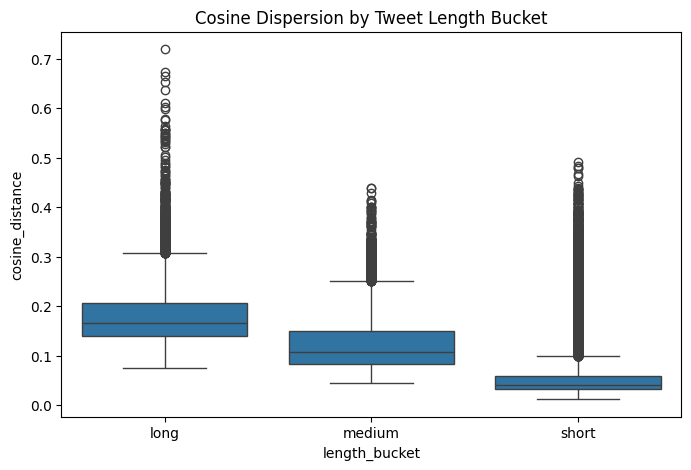

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Build full distance vector for boxplot
all_rows = []

for bucket in df_disp["length_bucket"].unique():
    
    sub = df_disp[df_disp["length_bucket"] == bucket]
    idx = sub["embedding_matrix_index"].values
    
    emb = X[idx]
    centroid = emb.mean(axis=0, keepdims=True)
    
    sims = cosine_similarity(emb, centroid).flatten()
    distances = 1 - sims
    
    for d in distances:
        all_rows.append({"length_bucket": bucket, "cosine_distance": d})

df_box = pd.DataFrame(all_rows)

plt.figure(figsize=(8,5))
sns.boxplot(data=df_box, x="length_bucket", y="cosine_distance")
plt.title("Cosine Dispersion by Tweet Length Bucket")
plt.show()